In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
def create_ages(mu=50, sigma=13, num_samples=100, seed=42) :
    np.random.seed(seed)

    sample_ages = np.random.normal(loc=mu, scale=sigma, size=num_samples)
    sample_ages = np.round(sample_ages, decimals=0)

    return sample_ages

In [4]:
sample = create_ages()

In [5]:
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

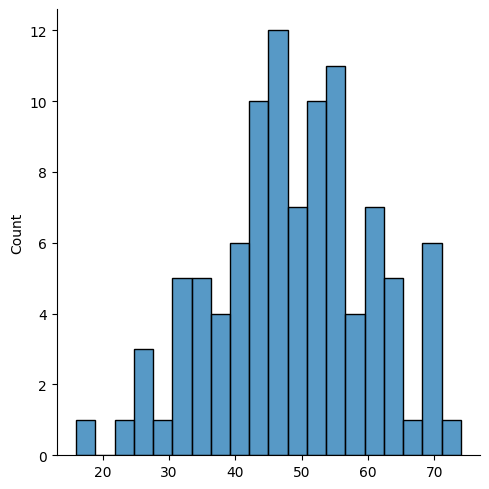

In [7]:
sns.displot(sample, bins=20)

<Axes: >

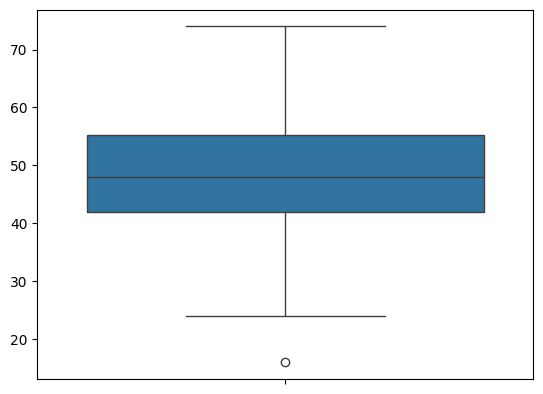

In [8]:
sns.boxplot(sample)

In [9]:
ser = pd.Series(sample)

In [10]:
ser.describe()

count    100.00000
mean      48.66000
std       11.82039
min       16.00000
25%       42.00000
50%       48.00000
75%       55.25000
max       74.00000
dtype: float64

In [11]:
IQR = 55.25000 - 42.00000
lower_limit = 42.00000 - 1.5 * IQR

In [12]:
lower_limit

22.125

In [14]:
ser[ser > lower_limit]

0     56.0
1     48.0
2     58.0
3     70.0
4     47.0
      ... 
95    31.0
96    54.0
97    53.0
98    50.0
99    47.0
Length: 99, dtype: float64

In [17]:
q_75, q_25 = np.percentile(sample, [75,25])

In [19]:
iqr = q_75 - q_25

In [20]:
1.5*iqr  

np.float64(19.875)

In [21]:
q_25 - 1.5*iqr

np.float64(22.125)

In [22]:
df = pd.read_csv("DATA/Ames_Housing_Data.csv")

In [23]:
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,923275080,80,RL,37.0,7937,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,GdPrv,NaN,0,3,2006,WD,Normal,142500
2926,923276100,20,RL,NaN,8885,Pave,NaN,IR1,Low,AllPub,...,0,NaN,MnPrv,NaN,0,6,2006,WD,Normal,131000
2927,923400125,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,132000
2928,924100070,20,RL,77.0,10010,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,170000


In [31]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

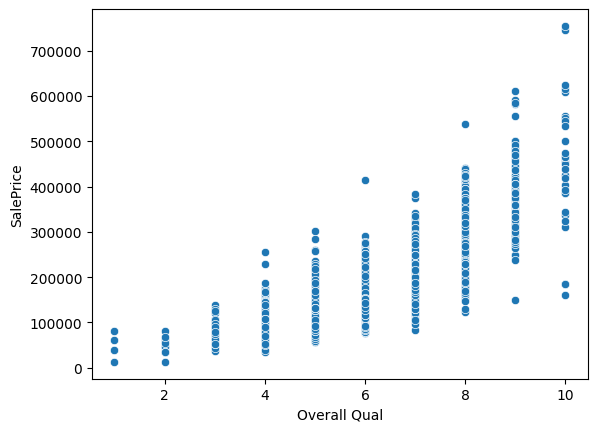

In [33]:
sns.scatterplot(x='Overall Qual', y='SalePrice', data=df)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

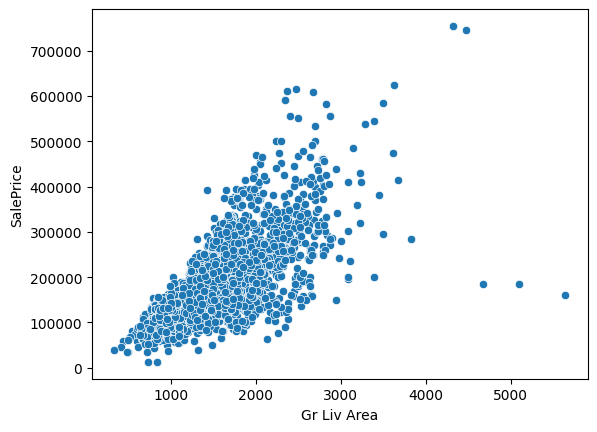

In [35]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

In [38]:
df[(df['Overall Qual'] > 8) & (df['SalePrice'] < 200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [39]:
df[(df['Gr Liv Area'] > 4250) & (df['SalePrice'] < 300000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [41]:
drop_ind = df[(df['Gr Liv Area'] > 4250) & (df['SalePrice'] < 300000)].index

In [42]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

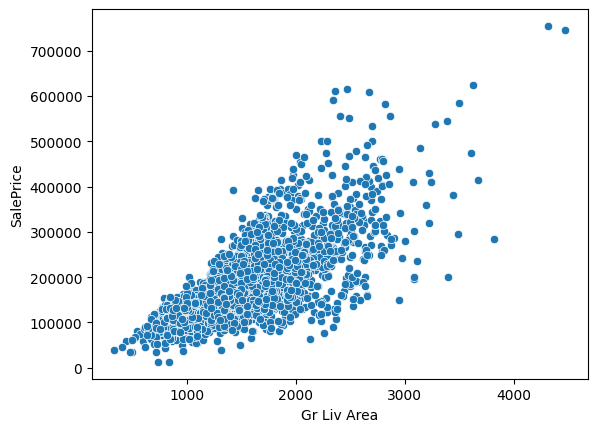

In [43]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

<Axes: xlabel='Garage Cars', ylabel='SalePrice'>

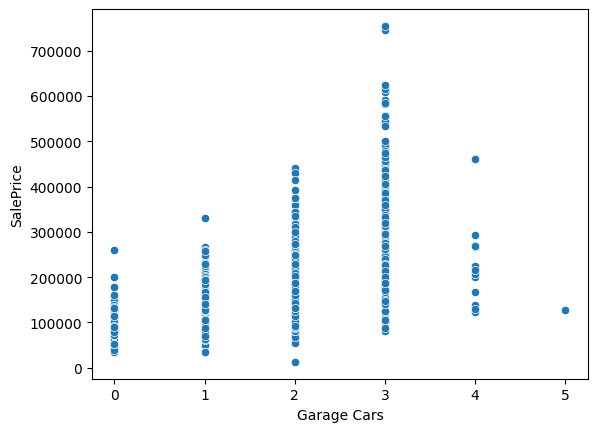

In [44]:
sns.scatterplot(x='Garage Cars', y='SalePrice', data=df)

In [45]:
df['Garage Cars'].value_counts()

Garage Cars
2.0    1602
1.0     778
3.0     372
0.0     157
4.0      16
5.0       1
Name: count, dtype: int64

In [57]:
delete_ind = df[
    ((df['Garage Cars'] == 3) & (df['SalePrice'] > 700000)) |
    ((df['Garage Cars'] == 4) & (df['SalePrice'] > 400000)) |
    ((df['Garage Cars'] == 5))
].index

In [58]:
delete_ind

Index([746, 1059, 1760, 1767], dtype='int64')

In [59]:
df = df.drop(delete_ind,axis=0)

<Axes: xlabel='Garage Cars', ylabel='SalePrice'>

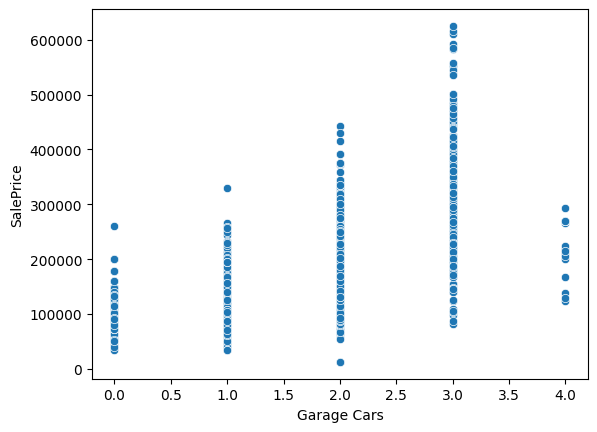

In [60]:
sns.scatterplot(x='Garage Cars', y='SalePrice', data=df)

<Axes: xlabel='Total Bsmt SF', ylabel='SalePrice'>

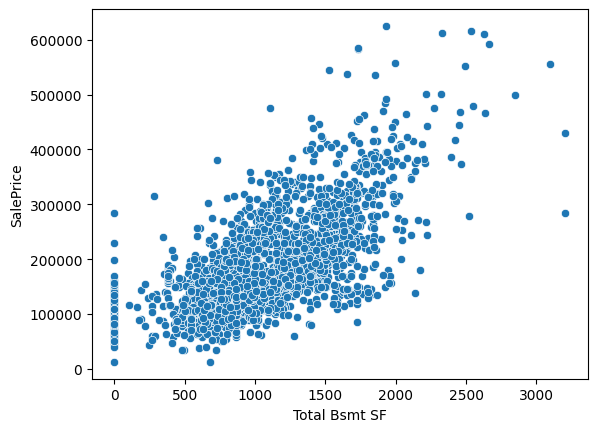

In [62]:
sns.scatterplot(x='Total Bsmt SF', y='SalePrice', data=df)

In [65]:
drop_ind = df[(df['Total Bsmt SF'] > 3000) & (df['SalePrice'] < 310000)].index

In [66]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Total Bsmt SF', ylabel='SalePrice'>

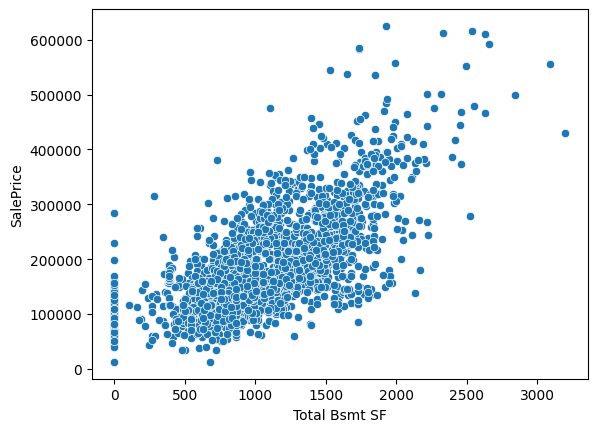

In [67]:
sns.scatterplot(x='Total Bsmt SF', y='SalePrice', data=df)

<Axes: xlabel='1st Flr SF', ylabel='SalePrice'>

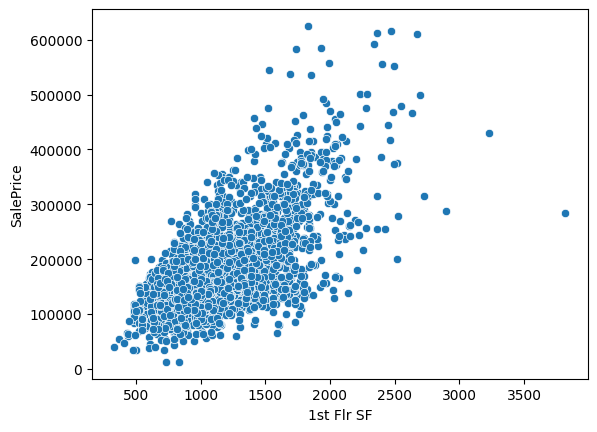

In [68]:
sns.scatterplot(x='1st Flr SF', y='SalePrice', data=df)

In [69]:
drop_ind = df[(df['1st Flr SF'] > 3700) & (df['SalePrice'] < 300000)].index

In [70]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='1st Flr SF', ylabel='SalePrice'>

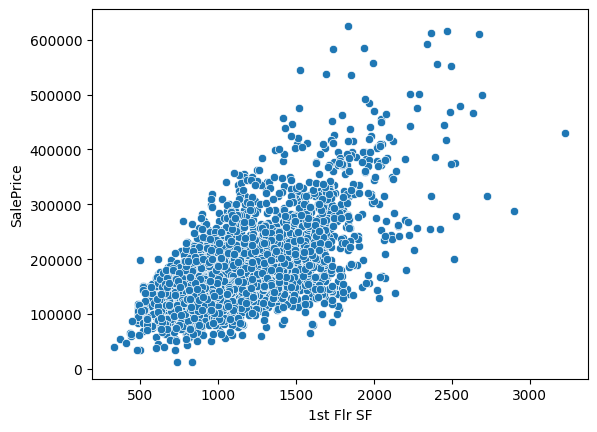

In [71]:
sns.scatterplot(x='1st Flr SF', y='SalePrice', data=df)

<Axes: xlabel='Year Built', ylabel='SalePrice'>

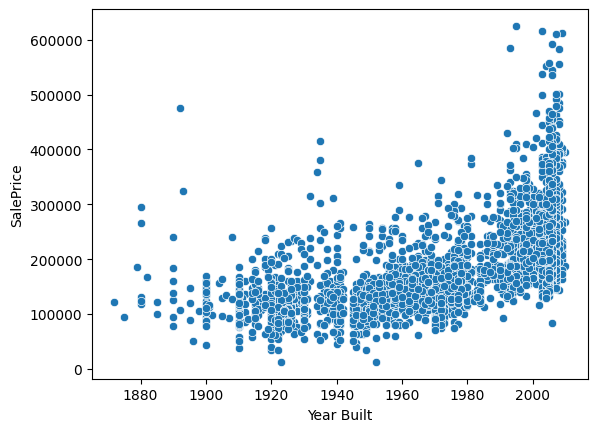

In [72]:
sns.scatterplot(x='Year Built', y='SalePrice', data=df)

In [73]:
drop_ind = df[(df['Year Built'] < 1900) & (df['SalePrice'] > 430000)].index

In [74]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Year Built', ylabel='SalePrice'>

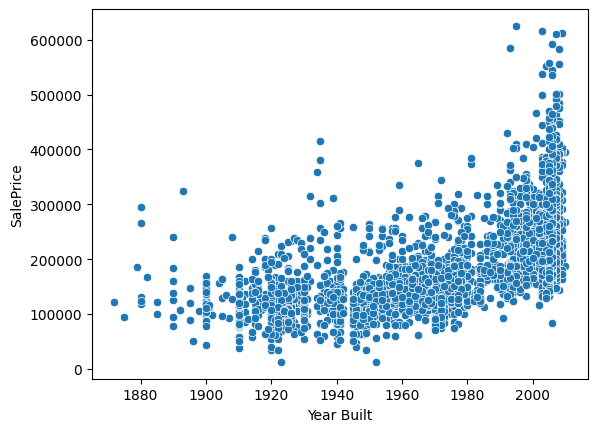

In [75]:
sns.scatterplot(x='Year Built', y='SalePrice', data=df)

<Axes: xlabel='Full Bath', ylabel='SalePrice'>

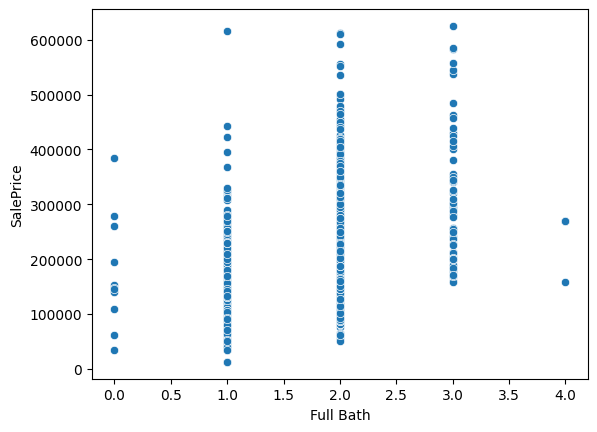

In [76]:
sns.scatterplot(x='Full Bath', y='SalePrice', data=df)

In [77]:
drop_ind = df[(df['Full Bath'] == 1) & (df['SalePrice'] > 575000)].index

In [78]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Full Bath', ylabel='SalePrice'>

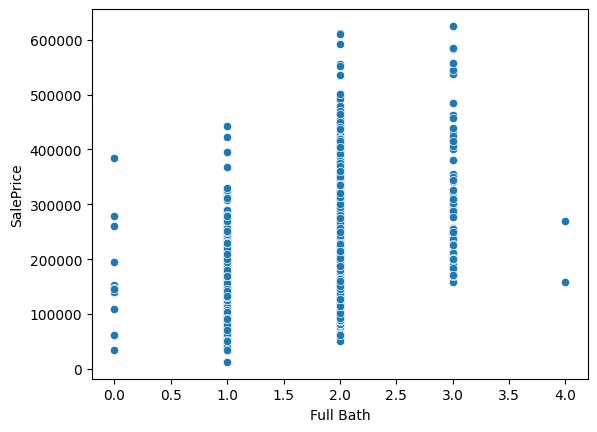

In [79]:
sns.scatterplot(x='Full Bath', y='SalePrice', data=df)

<Axes: xlabel='Year Remod/Add', ylabel='SalePrice'>

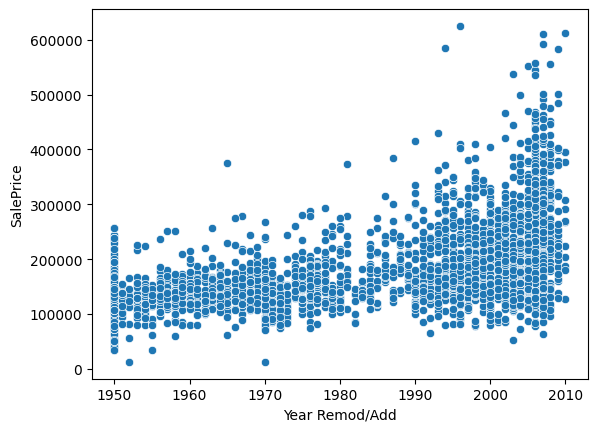

In [80]:
sns.scatterplot(x='Year Remod/Add', y='SalePrice', data=df)

In [81]:
drop_ind = df[
    ((df['Year Remod/Add'] < 1970) & (df['SalePrice'] < 400000)) |
    ((df['Year Remod/Add'] < 2000) & (df['SalePrice'] > 550000))
].index

In [83]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Year Remod/Add', ylabel='SalePrice'>

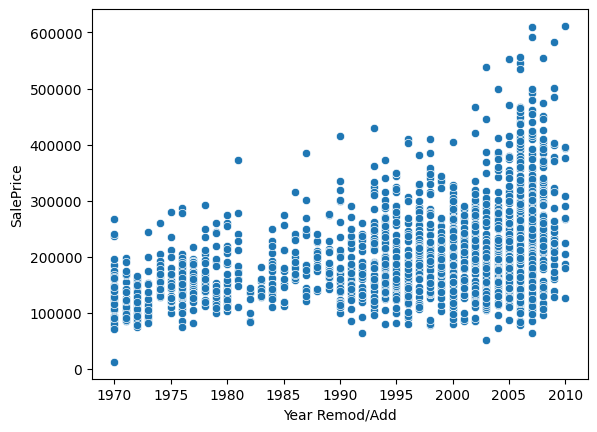

In [84]:
sns.scatterplot(x='Year Remod/Add', y='SalePrice', data=df)

<Axes: xlabel='Garage Yr Blt', ylabel='SalePrice'>

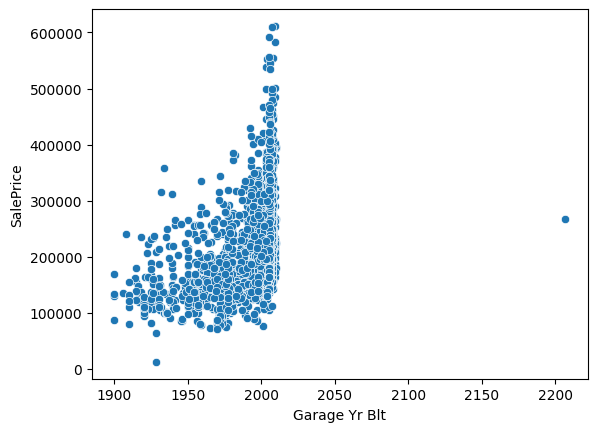

In [85]:
sns.scatterplot(x='Garage Yr Blt', y='SalePrice', data=df)

In [93]:
drop_ind = df[df['Garage Yr Blt'] > 2200].index

In [94]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Garage Yr Blt', ylabel='SalePrice'>

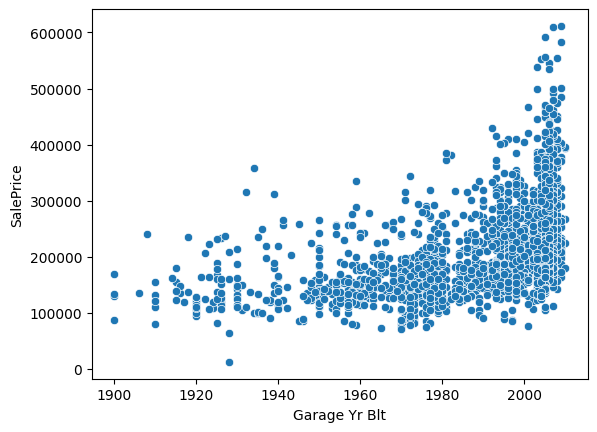

In [95]:
sns.scatterplot(x='Garage Yr Blt', y='SalePrice', data=df)

<Axes: xlabel='Mas Vnr Area', ylabel='SalePrice'>

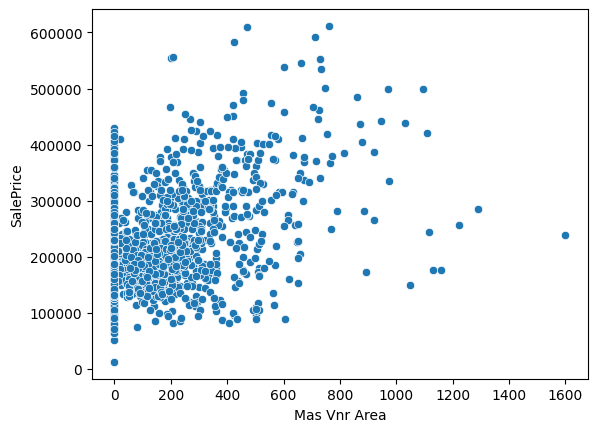

In [96]:
sns.scatterplot(x='Mas Vnr Area', y='SalePrice', data=df)

In [97]:
drop_ind = df[df['Mas Vnr Area'] > 1550].index

In [98]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Mas Vnr Area', ylabel='SalePrice'>

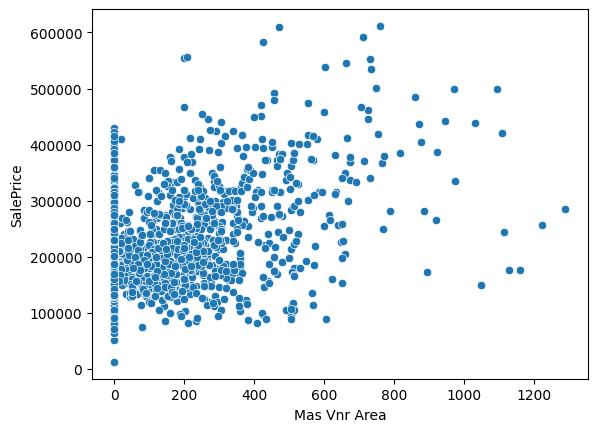

In [99]:
sns.scatterplot(x='Mas Vnr Area', y='SalePrice', data=df)

<Axes: xlabel='TotRms AbvGrd', ylabel='SalePrice'>

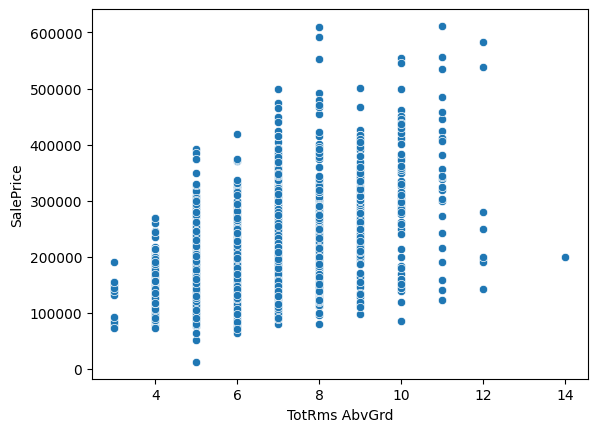

In [100]:
sns.scatterplot(x='TotRms AbvGrd', y='SalePrice', data=df)

In [103]:
df[df['TotRms AbvGrd'] == 14][
    ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Year Built']
]

,SalePrice,Gr Liv Area,Overall Qual,Year Built
2194,200000,3395,6,1914


<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

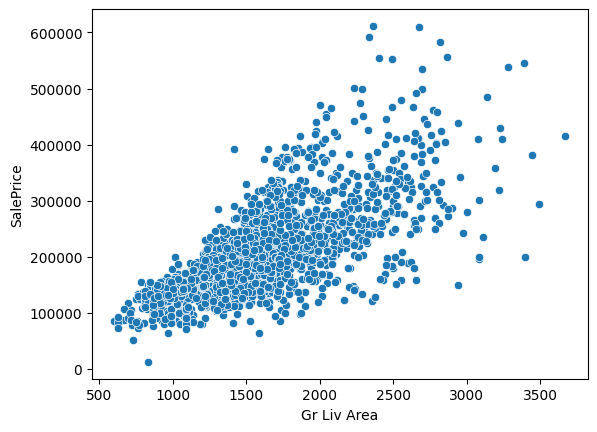

In [104]:
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

<Axes: xlabel='Fireplaces', ylabel='SalePrice'>

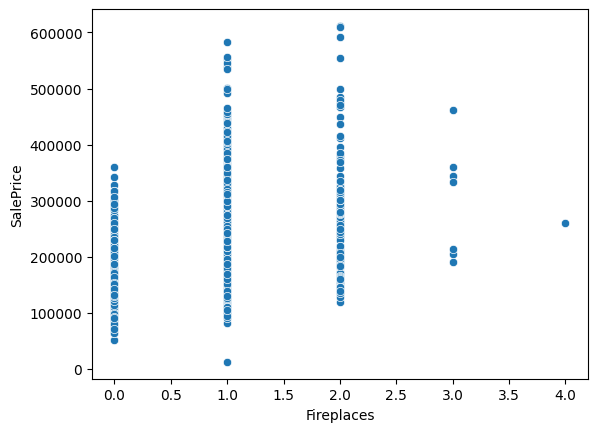

In [105]:
sns.scatterplot(x='Fireplaces', y='SalePrice', data=df)

In [110]:
df[(df['Fireplaces'] == 1) & (df['SalePrice'] < 50000)][
    ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Year Built']
]

,SalePrice,Gr Liv Area,Overall Qual,Year Built
181,12789,832,2,1923


<Axes: xlabel='BsmtFin SF 1', ylabel='SalePrice'>

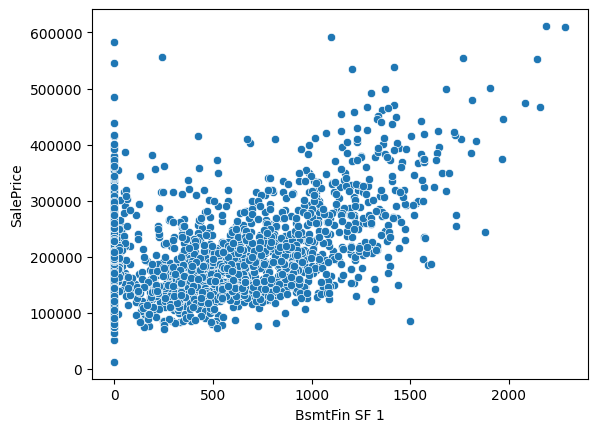

In [111]:
sns.scatterplot(x='BsmtFin SF 1', y='SalePrice', data=df)

<Axes: xlabel='Lot Frontage', ylabel='SalePrice'>

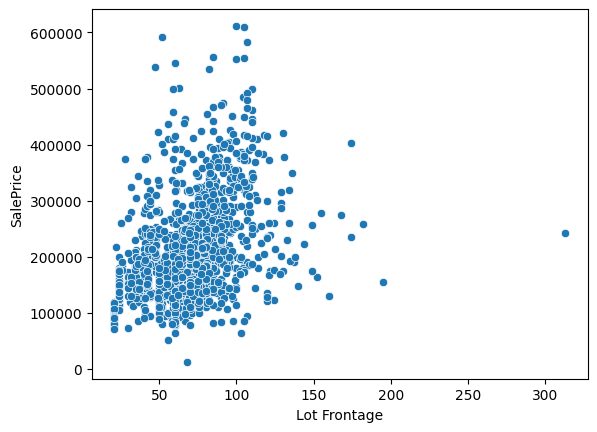

In [112]:
sns.scatterplot(x='Lot Frontage', y='SalePrice', data=df)

In [113]:
df[df['Lot Frontage'] > 300][
    ['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Year Built']
]

,SalePrice,Gr Liv Area,Overall Qual,Year Built
1265,242000,2069,7,1960


<Axes: xlabel='Wood Deck SF', ylabel='SalePrice'>

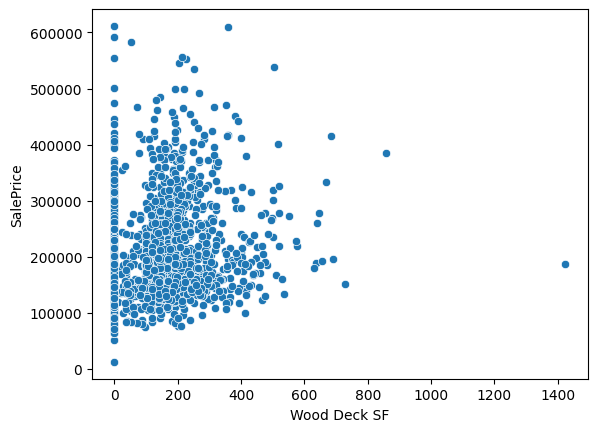

In [115]:
sns.scatterplot(x='Wood Deck SF', y='SalePrice', data=df)

In [117]:
drop_ind = df[df['Wood Deck SF'] > 1200].index

In [118]:
df = df.drop(drop_ind, axis=0)

<Axes: xlabel='Wood Deck SF', ylabel='SalePrice'>

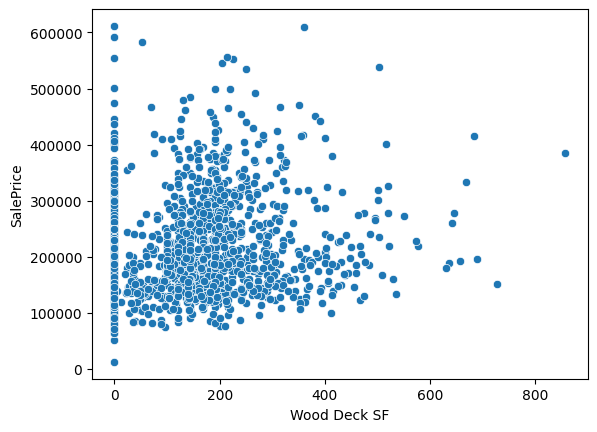

In [119]:
sns.scatterplot(x='Wood Deck SF', y='SalePrice', data=df)

<Axes: xlabel='Open Porch SF', ylabel='SalePrice'>

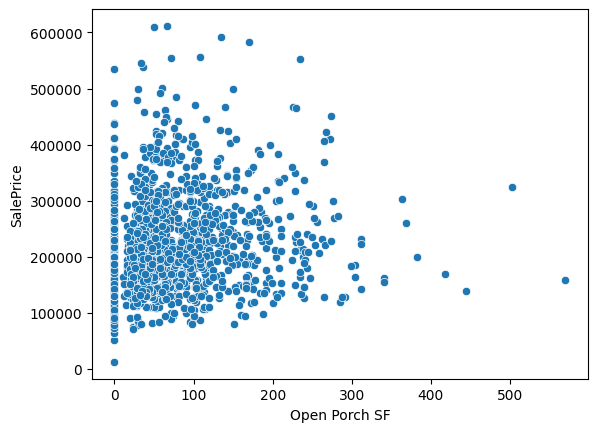

In [120]:
sns.scatterplot(x='Open Porch SF', y='SalePrice', data=df)

In [128]:
df.to_csv('DATA/Ames_my_outliers_removed', index=False)